Load required Libraries and Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itables import show
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [23]:
data = pd.read_csv("C:\\Users\\kings\\Desktop\\Sample - Superstore.csv")
#show(data) 
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/08/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/08/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [4]:
## Data quality assessment
data.shape #view the dimension of the dataset
data.isna().sum() #check for missing value by column

#Assess data type
data.dtypes
#convert order date and ship date to date_time format
data["Order Date"] = pd.to_datetime(data["Order Date"])
data["Ship Date"] = pd.to_datetime(data["Ship Date"])

##feature derivation
data["Days to ship"] = (data["Ship Date"] - data["Order Date"])

Sales Analysis (Where is the money comig from?)

In [5]:
data["Segment"].unique()
data.shape

(9994, 22)

                    Sales
Segment                  
Consumer     1.161401e+06
Corporate    7.061464e+05
Home Office  4.296531e+05


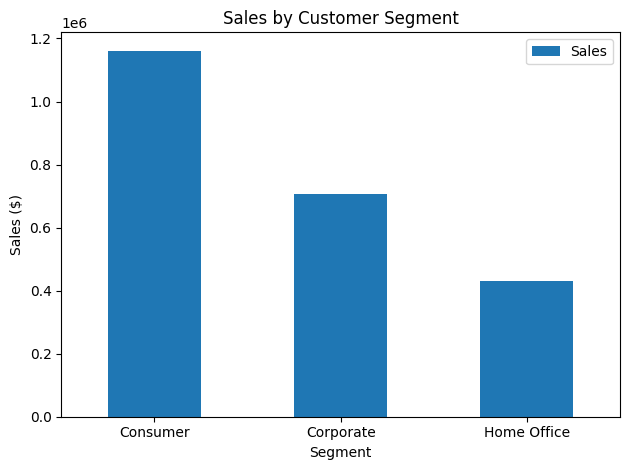

In [6]:
##Total sales by customer segment (Consumer, Corporate, Home office)
seg_sales = data.groupby("Segment")[["Sales"]].sum().sort_values(by = "Sales", ascending = False)
print(seg_sales)

#plot sales by segment
seg_sales.plot(kind = "bar")
plt.title("Sales by Customer Segment")
plt.ylabel("Sales ($)")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [7]:
data["Region"].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

               Sales
Region              
West     725457.8245
East     678781.2400
Central  501239.8908
South    391721.9050


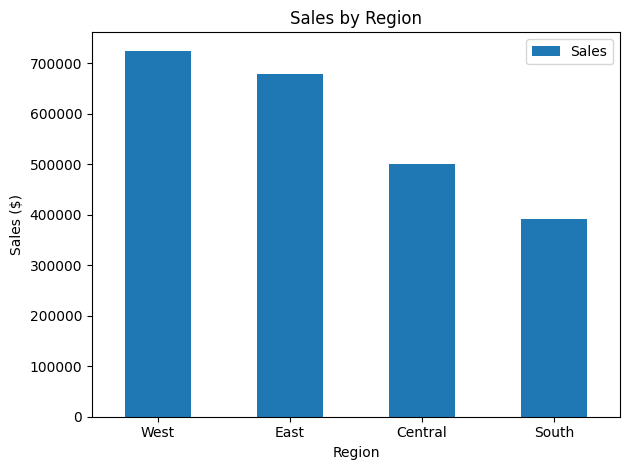

In [8]:
##Total sales by region 
reg_sales = data.groupby("Region")[["Sales"]].sum().sort_values(by = "Sales", ascending = False)
print(reg_sales)

#plot sales by region
reg_sales.plot(kind = "bar")
plt.title("Sales by Region")
plt.ylabel("Sales ($)")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

                  Sales
Order Date             
2014-01-31   14236.8950
2014-02-28    4519.8920
2014-03-31   55691.0090
2014-04-30   28295.3450
2014-05-31   23648.2870
2014-06-30   34595.1276
2014-07-31   33946.3930
2014-08-31   27909.4685
2014-09-30   81777.3508
2014-10-31   31453.3930
2014-11-30   78628.7167
2014-12-31   69545.6205
2015-01-31   18174.0756
2015-02-28   11951.4110
2015-03-31   38726.2520
2015-04-30   34195.2085
2015-05-31   30131.6865
2015-06-30   24797.2920
2015-07-31   28765.3250
2015-08-31   36898.3322
2015-09-30   64595.9180
2015-10-31   31404.9235
2015-11-30   75972.5635
2015-12-31   74919.5212
2016-01-31   18542.4910
2016-02-29   22978.8150
2016-03-31   51715.8750
2016-04-30   38750.0390
2016-05-31   56987.7280
2016-06-30   40344.5340
2016-07-31   39261.9630
2016-08-31   31115.3743
2016-09-30   73410.0249
2016-10-31   59687.7450
2016-11-30   79411.9658
2016-12-31   96999.0430
2017-01-31   43971.3740
2017-02-28   20301.1334
2017-03-31   58872.3528
2017-04-30   365

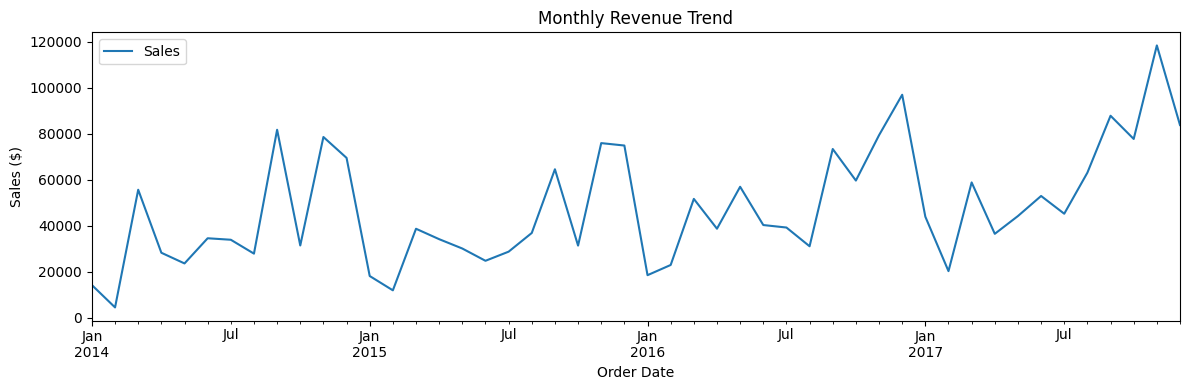

In [9]:
##Monthly Revenue
monthly = data.resample("ME", on = "Order Date")[["Sales"]].sum()
print(monthly)

#plot monthly revenue
monthly.plot(figsize = (12, 4))
plt.title("Monthly Revenue Trend")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()

In [10]:
##Sales Breakdown by segment and Category
pivot = data.pivot_table(
    values = "Sales",
    index = "Segment",  #rows
    columns = "Category", #columns
    aggfunc = "sum"
)

print(pivot.round(0))

Category     Furniture  Office Supplies  Technology
Segment                                            
Consumer      391049.0         363952.0    406400.0
Corporate     229020.0         230676.0    246450.0
Home Office   121931.0         124418.0    183304.0


Profitability Modelling (Are discounts hurting us?)

In [11]:
##Create a new feature (Profit Margin)
#Profit Margin = Profit/Sales
data["Profit Margin"] = data["Profit"] / data["Sales"]

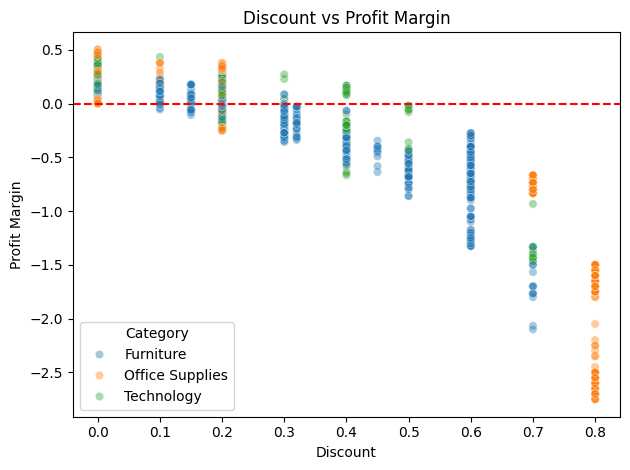

In [12]:
#Discount vs Profit Margin
sns.scatterplot(data = data, x = "Discount", y = "Profit Margin", hue = "Category", alpha = 0.4)
plt.axhline(0, color = "red", linestyle = "--")
plt.title("Discount vs Profit Margin")
plt.tight_layout()
plt.show()

                     Profit
Discount band              
No discount       66.900292
Low (0-20%)       26.501571
Medium (20-40%)  -77.864055
High (40%+)     -106.708028


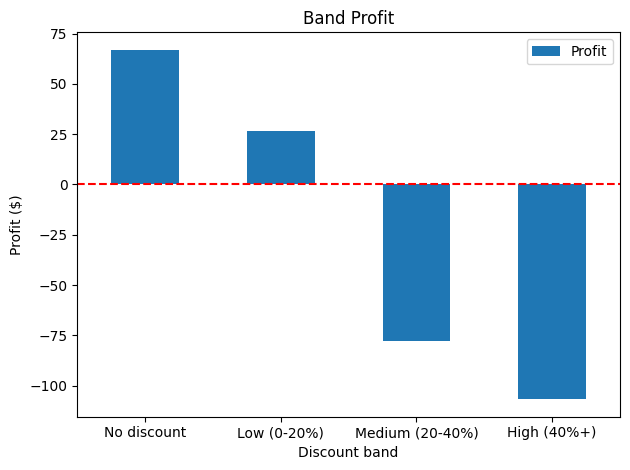

In [13]:
#group discounts into bands
data["Discount band"] = pd.cut(
    data["Discount"],
    bins = [-0.01, 0, 0.2, 0.4, 0.8],
    labels = ["No discount", "Low (0-20%)", "Medium (20-40%)", "High (40%+)"]
)

##Average profit per band
band_profit = data.groupby("Discount band", observed = True)[["Profit"]].mean()
print(band_profit)

#plot band profit
band_profit.plot(kind = "bar")
plt.axhline(0, color = "red", linestyle = "--")
plt.title("Band Profit")
plt.xticks(rotation = 0)
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

In [14]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Days to ship', 'Profit Margin', 'Discount band'],
      dtype='object')

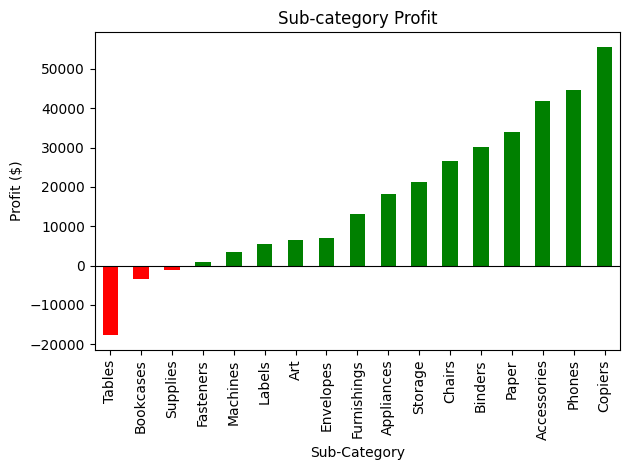

In [15]:
#Which sub-categories are loosing money?
subcat_profit = data.groupby("Sub-Category")["Profit"].sum().sort_values()
colors = ["red" if x < 0 else "green" for x in subcat_profit]

#plot sub-category profit
subcat_profit.plot(kind = "bar", color = colors)
plt.axhline(0, color = "black", linewidth = 0.8)
plt.title("Sub-category Profit")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

Customer Segmentation (Who are our most valuable customer?)

In [16]:
# snapshot_date is just "the day after the last order in the dataset"
# We use it as our reference point for calculating how many days ago each customer bought
snapshot_date = data["Order Date"].max() + pd.Timedelta(days=1)

# This collapses the entire dataset (9994 rows) into one row per customer (793 rows)
rfm = data.groupby("Customer ID").agg(
    Recency   = ("Order Date", lambda x: (snapshot_date - x.max()).days),
    #days between their most recent order and our snapshot date
    Frequency = ("Order ID", "nunique"),
    #count of unique orders (not rows — one order can have many product rows)
    Monetary  = ("Sales", "sum")
    #total money spent across all their orders
).reset_index()

print(rfm.head(10))

  Customer ID  Recency  Frequency   Monetary
0    AA-10315      185          5   5563.560
1    AA-10375       20          9   1056.390
2    AA-10480      260          4   1790.512
3    AA-10645       56          6   5086.935
4    AB-10015      416          3    886.156
5    AB-10060       55          8   7755.620
6    AB-10105       42         10  14473.571
7    AB-10150       42          5    966.710
8    AB-10165       26          8   1113.838
9    AB-10255      167          9    914.532


In [17]:
# Problem: Monetary goes up to $10,000. Frequency only goes up to 14.
# K-Means groups by distance — without scaling, spend dominates everything else
# StandardScaler converts all three columns to the same scale (mean=0, std=1)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

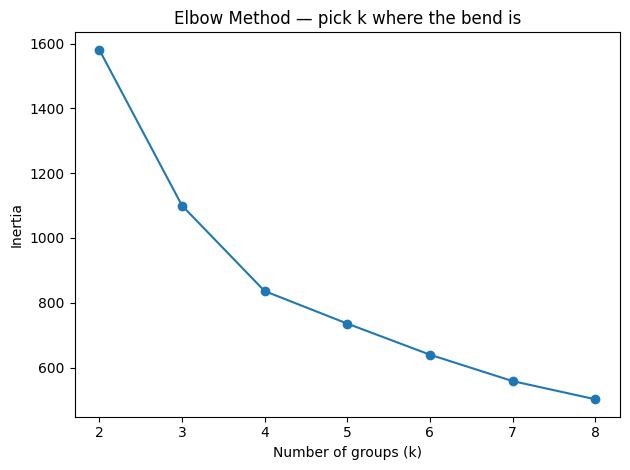

In [18]:
inertias = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(rfm_scaled)
    inertias.append(model.inertia_)

plt.plot(range(2, 9), inertias, marker='o')
plt.title("Elbow Method — pick k where the bend is")
plt.xlabel("Number of groups (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [19]:
# Set k to 4 since the elbow plot suggested so
k = 4

final_model = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm["Cluster"] = final_model.fit_predict(rfm_scaled)

In [20]:
profile = rfm.groupby('Cluster').agg(
    Count     = ("Customer ID", "count"),
    Recency   = ("Recency", "mean"),   # low = bought recently = good
    Frequency = ("Frequency", "mean"),   # high = buys often = good
    Monetary  = ("Monetary", "mean")    # high = spends more = good
).round(0)

print(profile)

         Count  Recency  Frequency  Monetary
Cluster                                     
0          298     73.0        9.0    3322.0
1          335    101.0        5.0    1670.0
2           64    124.0        8.0    9480.0
3           96    559.0        4.0    1470.0


In [21]:
label_map = {
    0: "Loyal Customers",   # recent, high frequency, good spend
    1: "Casual Customers",  # largest group, average on everything
    2: "Champions",         # small group but by far the highest spenders
    3: "At Risk"            # haven't bought in over 1.5 years
}

rfm["Segment"] = rfm["Cluster"].map(label_map)

# Confirm the counts match what you saw in the profile
print(rfm["Segment"].value_counts())

Segment
Casual Customers    335
Loyal Customers     298
At Risk              96
Champions            64
Name: count, dtype: int64


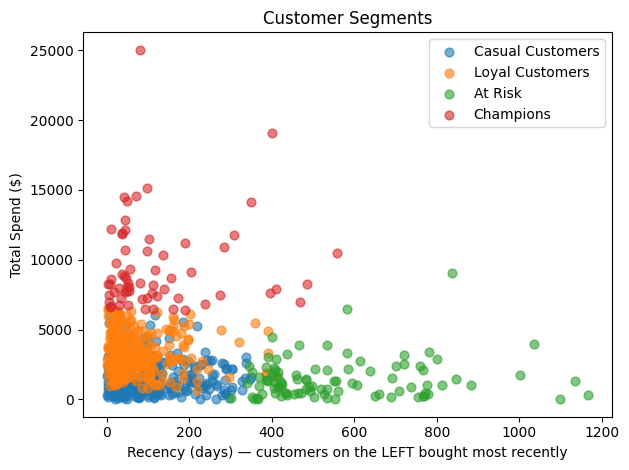

In [22]:
for cluster in rfm["Cluster"].unique():
    subset = rfm[rfm["Cluster"] == cluster]
    plt.scatter(subset["Recency"], subset["Monetary"],
                label=label_map[cluster], alpha=0.6, s=40)

plt.title("Customer Segments")
plt.xlabel("Recency (days) — customers on the LEFT bought most recently")
plt.ylabel("Total Spend ($)")
plt.legend()
plt.tight_layout()
plt.show()